# v1 — Baseline Piotroski (BM + F-score) บน S&P 500

**ทำอะไร:** สร้าง "วิธีเดิม" ของ Piotroski ใหม่จากข้อมูล SEC แบบ point-in-time แล้วแยกดู 3 พอร์ต (ablation)
- **P1 High BM** — หุ้น "ถูก" (book-to-market สูงสุด 20%)
- **P2 High F** — หุ้น "งบแข็งแรง" (F-score ≥ 7 จาก 9)
- **P3 High BM + High F** — ถูก *และ* แข็งแรง (พอร์ตหลักของ Piotroski)

เทียบกับ **EW universe** = ซื้อทุกตัวใน universe เดียวกันเท่า ๆ กัน (ตัวตัดสินหลัก)

**ทำไม:** งานวิจัยกับ S&P 500 ชี้ว่ากำไรของ Piotroski อาจมาจาก "ความถูก" มากกว่า "คุณภาพ" — ต้องแยกให้เห็น

**อุปมา:** เหมือนเลือกผลไม้ — P1 เลือกเฉพาะที่ "ราคาถูก", P2 เลือกเฉพาะที่ "สดดี", P3 เลือกที่ "ถูกและสด"
แล้วเทียบกับการ "ซื้อทุกลูกในแผง" (EW) ว่าการเลือกช่วยจริงไหม

**อ่านผลอย่างไร:**
- เกณฑ์ตัดสิน (ล็อกใน `PREREG.md` ก่อนรัน): **C1 = Sharpe ของ P3 > Sharpe ของ EW ในช่วง rebalance 2017–2022** (หลังหักต้นทุน 10 bps/ข้าง)
- ช่วง 2011–2016 เป็นข้อมูลประกอบเท่านั้น (survivorship gap สูง) — held-out (2023+) **ไม่ถูกโหลดเลย** ใน notebook นี้
- ตัวเลขทุกตัวมาจากการรันจริง; sensitivity 12 variant รายงานครบทุกตัว

In [1]:
import sys, pathlib, warnings
sys.path.insert(0, str(pathlib.Path.cwd().parent))
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from lib import build_data, constituents, prices, audit, report, cik_map, checks, fscore, universe, backtest as bt, sec_rss
from lib.pit import PIT
from lib.paths import INTERIM
np.random.seed(42)
pd.set_option("display.width", 220); pd.set_option("display.max_columns", 40); pd.set_option("display.float_format", "{:.4f}".format)
report.banner()
display(__import__("IPython").display.Markdown(
 "> ⚠️ **เทียบกับ SPY/RSP**: พอร์ตและ EW ของเราไม่มีหุ้นที่หาราคาไม่ได้ (ส่วนใหญ่คือหุ้นที่ถูกซื้อ/ล้มละลาย) "
 "แต่ SPY/RSP ถือหุ้นเหล่านั้นจริง → การเทียบกับ SPY/RSP **เอียงเข้าข้างพอร์ตของเรา** ใช้ EW universe เป็นตัวตัดสิน"))


> ⚠️ **คำเตือน survivorship bias (แสดงในทุก notebook)**
> รายชื่อสมาชิกมาจาก fja05680/sp500 (point-in-time) แต่ **ราคามาจาก yfinance ซึ่งเก็บเฉพาะหุ้นที่ยังซื้อขายอยู่**
> หุ้นที่ถูกซื้อกิจการ/ล้มละลาย/เปลี่ยนชื่อจำนวนหนึ่งจึงไม่มีราคา และหลุดออกจาก backtest
> ผลตอบแทนที่คำนวณได้จึงมีแนวโน้ม **สูงกว่าความจริง** (หุ้นที่ "ตาย" ไปมักเป็นหุ้นที่ผลตอบแทนแย่)
> สัดส่วนที่ขาดหายวัดไว้ใน `v0_data_audit.ipynb`

> ⚠️ **ข้อจำกัดของ held-out**: held-out = rebalance มิ.ย. 2023, 2024, 2025 (3 รอบเต็ม) + มิ.ย. 2026 ที่ถือได้แค่ ~3 เดือน
> (รอบ 2026 เป็นข้อมูลประกอบ ไม่นับตัดสิน) — มีแค่ 2–3 รอบ rebalance ที่ใช้ตัดสิน ผลช่วงนี้จึงมีความไม่แน่นอนสูงมาก
> ใช้เป็นการตรวจทิศทางเท่านั้น ไม่ใช่หลักฐานทางสถิติ


> ⚠️ **เทียบกับ SPY/RSP**: พอร์ตและ EW ของเราไม่มีหุ้นที่หาราคาไม่ได้ (ส่วนใหญ่คือหุ้นที่ถูกซื้อ/ล้มละลาย) แต่ SPY/RSP ถือหุ้นเหล่านั้นจริง → การเทียบกับ SPY/RSP **เอียงเข้าข้างพอร์ตของเรา** ใช้ EW universe เป็นตัวตัดสิน

## 0) ข้อมูลและ held-out guard

In [2]:
END = pd.Timestamp("2023-06-30")          # ห้ามโหลดข้อมูลหลังวันนี้ (held-out เริ่มที่ rebalance มิ.ย. 2023)
build_data.run()
hist = constituents.load_history()
segs = build_data.build_segments(build_data.build_spells())
long, wide = build_data.build_facts(segs)
pit = PIT(long)
adj = prices.load_adj_close().loc[:END]; close = prices.load_close().loc[:END]
# ประวัติ split ใช้ "ทั้งหมด" รวมหลัง END: ราคา Close ของ Yahoo ถูกปรับย้อนหลังด้วย split ในอนาคตแล้ว (เช่น NVDA 10:1 ปี 2024)
# การใช้ split หลัง END จึงเป็นการ "ถอดการปรับ" ให้ได้ราคาจริง ณ วันนั้น ไม่ใช่การมองอนาคต
# (บั๊กรอบแรกของ v1: ตัด split ที่ END ทำให้ market cap ของ NVDA ปี 2017 เล็กไป 10 เท่า → เจอและแก้ก่อนสรุปผล)
splits = prices.load_splits()
assert adj.index.max() <= END and close.index.max() <= END, "held-out guard: มีราคาหลัง END"
rss = sec_rss.load_all()
sic_of = rss.sort_values("filed").dropna(subset=["sic"]).groupby("cik").sic.last().to_dict()
cur = cik_map.load_current_map(); inv = {}
for tk, c in cur.items(): inv.setdefault(c, []).append(tk)
cik_ticker = {c: audit.common_ticker(v) for c, v in inv.items()}
Rs = audit.rebalance_dates(adj["SPY"].dropna().index, range(2011, 2023))
print("rebalance:", [r.date() for r in Rs]); print("ราคาล่าสุดที่โหลด:", adj.index.max().date())

SEC RSS: 210 เดือน, 424,287 filings (cache: /Users/boeing/Desktop/SNP-claude/model_A/data/raw/sec/xbrlrss_parsed)


rebalance: [datetime.date(2011, 6, 30), datetime.date(2012, 6, 29), datetime.date(2013, 6, 28), datetime.date(2014, 6, 30), datetime.date(2015, 6, 30), datetime.date(2016, 6, 30), datetime.date(2017, 6, 30), datetime.date(2018, 6, 29), datetime.date(2019, 6, 28), datetime.date(2020, 6, 30), datetime.date(2021, 6, 30), datetime.date(2022, 6, 30)]
ราคาล่าสุดที่โหลด: 2023-06-30


## 1) คะแนน BM และ F-score ต่อหุ้นต่อรอบ (ทุก variant)

In [3]:
p = INTERIM / "v1_scores.parquet"
scores = universe.build_scores(hist, segs, pit, adj, close, splits, Rs, constituents.to_yahoo, sic_of, cik_ticker,
                               prices.split_factor_after)
scores.to_parquet(p, index=False)
checks.nonempty(scores, "v1 scores", 5000)
checks.members_per_R(scores)
checks.no_sudden_drop(scores, "elig_main")
u = scores.groupby("R").agg(members=("ticker","size"), financial=("financial","sum"),
        no_price_or_mcap=("price_flag", lambda s: (s != "ok").sum()),
        bm_le_0=("BM", lambda s: (s <= 0).sum()),
        elig_main=("elig_main","sum"), elig_S1=("elig_S1","sum"), elig_S2=("elig_S2","sum"), elig_S3=("elig_S3","sum"))
u.index = u.index.date
print("universe ต่อรอบ (no_price_or_mcap นับทุก sector; bm_le_0 = หุ้น equity ≤ 0 ที่อยู่ใน universe แต่ไม่ถูกจัดอันดับ BM)")
display(u)

universe ต่อรอบ (no_price_or_mcap นับทุก sector; bm_le_0 = หุ้น equity ≤ 0 ที่อยู่ใน universe แต่ไม่ถูกจัดอันดับ BM)


,members,financial,no_price_or_mcap,bm_le_0,elig_main,elig_S1,elig_S2,elig_S3
2011-06-30,497,86,173,4,169,254,174,168
2012-06-29,497,85,150,6,238,275,246,237
2013-06-28,497,83,142,7,259,285,266,258
2014-06-30,498,85,133,6,266,293,272,265
2015-06-30,499,89,122,8,275,300,280,274
2016-06-30,505,95,102,13,292,318,299,291
2017-06-30,506,100,92,17,300,326,306,299
2018-06-29,506,103,81,17,309,336,316,308
2019-06-28,505,101,73,24,308,343,320,307
2020-06-30,505,97,57,24,322,359,332,321


### 1.1 ตรวจ market cap ด้วยแหล่งอิสระ (EntityPublicFloat จากหน้าปก 10-K)
public float = มูลค่าหุ้นที่คนนอกถือ ณ วันทำการสุดท้ายของไตรมาส 2 ของบริษัท (ปีบัญชีปกติ = 30 มิ.ย. ตรงกับ R)
ควรได้ market cap / float ≈ 1 (มากกว่า 1 เล็กน้อยเพราะ float ไม่รวมหุ้นของผู้บริหาร) — ใช้ตรวจเท่านั้น ไม่ใช้ตัดสินใจ

In [4]:
from lib import sec_facts
e = scores[scores.elig_main & scores.cik.notna()]
pf = pd.concat([sec_facts.public_float(int(c)) for c in e.cik.unique()], ignore_index=True)
print(f"public float ที่ค่า <= 0 (ตัดออกจากการตรวจ): {int((pf.val <= 0).sum())}"); pf = pf[pf.val > 0]
chk = []
for r in e.itertuples():
    x = pf[(pf.cik == r.cik) & ((pf.end - r.R).abs() <= pd.Timedelta(days=10))]
    if len(x): chk.append({"R": r.R, "ticker": r.ticker, "mcap_R": r.mcap_R, "float": x.val.iloc[0], "ratio": r.mcap_R / x.val.iloc[0]})
chk = pd.DataFrame(chk)
print(f"จับคู่ได้ {len(chk)} จาก {len(e)} หุ้น-รอบ (float วัด ณ วันห่างจาก R ≤ 10 วัน)")
print(chk.ratio.describe(percentiles=[.01,.05,.25,.5,.75,.95,.99]).round(3).to_string())
bad = chk[(chk.ratio < 0.7) | (chk.ratio > 3)]
print(f"ratio < 0.7 หรือ > 3: {len(bad)} ({len(bad)/len(chk):.1%})"); display(bad.sort_values("ratio").head(25))
# ratio < 0.01 หรือ > 100 = public float ใน XBRL ผิดหลัก (เช่น EBAY 3×10^19, DUK รายงานเป็นพัน) — ไม่ใช่ market cap ของเราผิด
sane = chk[(chk.ratio >= 0.01) & (chk.ratio <= 100)]
print(f"ตัดค่า float ผิดหลัก {len(chk) - len(sane)} ตัว; ที่เหลือ ratio < 0.7 = {(sane.ratio < 0.7).mean():.2%}")
assert 0.9 <= sane.ratio.median() <= 1.5, "median ของ market cap / public float ผิดปกติ"
assert (sane.ratio < 0.7).mean() < 0.01, "market cap ต่ำกว่า float เกิน 30% ใน > 1% ของหุ้น — สงสัยบั๊ก split/shares/ticker"
# รอบก่อนหน้าของ v1 assertion นี้ fire ไม่ได้เพราะเกณฑ์หลวม (ratio < 0.5 < 2%) แต่มีบั๊ก split (AMZN) และ ticker reuse (IR) อยู่
# ที่เหลือ < 0.7 ส่วนใหญ่เป็นบริษัทที่ออกหุ้นควบรวมหลังวันนับหุ้นบนหน้าปก (ข้อจำกัดของการใช้แค่ 10-K)

public float ที่ค่า <= 0 (ตัดออกจากการตรวจ): 26


จับคู่ได้ 2299 จาก 3442 หุ้น-รอบ (float วัด ณ วันห่างจาก R ≤ 10 วัน)
count        2299.0000
mean       434640.2660
std      20839916.6370
min             0.0000
1%              0.7790
5%              0.9790
25%             1.0010
50%             1.0140
75%             1.0810
95%             1.3870
99%             2.1340
max     999230000.1940
ratio < 0.7 หรือ > 3: 25 (1.1%)


,R,ticker,mcap_R,float,ratio
1432,2019-06-28,EBAY,36137777814.5000,31354367947000000000,0.0000
2047,2021-06-30,ZBH,33427322787.6047,33533707317000000,0.0000
1806,2020-06-30,ZBH,24636338414.9399,24675479718000000,0.0000
2286,2022-06-30,WAT,20029460572.4445,20209471189000,0.0010
1259,2018-06-29,GRMN,12082722498.0000,7753502173000,0.0016
675,2015-06-30,GRMN,9140841036.2402,5634428735000,0.0016
1057,2017-06-30,GRMN,10107890398.7463,6129443292000,0.0016
2230,2022-06-30,PARA,6307440000.0000,14437112130,0.4369
1573,2019-06-28,WAB,6932971331.9883,12700000000,0.5459
1695,2020-06-30,IR,5770554891.5406,10500000000,0.5496


ตัดค่า float ผิดหลัก 13 ตัว; ที่เหลือ ratio < 0.7 = 0.48%


## 2) พอร์ตต่อรอบ และจำนวนหุ้น (⚠️ = P3 น้อยกว่า 20 ตัว)

In [5]:
PORTS = ["EW", "P1", "P2", "P3"]
VARS = ["main", "S1", "S2", "S3"]
hold = {v: universe.portfolios(scores, v) for v in VARS}
cnt = pd.DataFrame({k: {R: len(hold["main"][R][k]) for R in Rs} for k in PORTS})
cnt["P3_flag"] = np.where(cnt.P3 < 20, "⚠️ < 20", "")
cnt.index = cnt.index.date
display(cnt)
print("รอบที่ P3 < 20 ตัว:", list(cnt.index[cnt.P3 < 20]))

,EW,P1,P2,P3,P3_flag
2011-06-30,169,34,77,12,⚠️ < 20
2012-06-29,238,47,73,8,⚠️ < 20
2013-06-28,259,51,70,5,⚠️ < 20
2014-06-30,266,52,88,12,⚠️ < 20
2015-06-30,275,54,86,11,⚠️ < 20
2016-06-30,290,56,67,3,⚠️ < 20
2017-06-30,297,57,103,8,⚠️ < 20
2018-06-29,306,59,100,7,⚠️ < 20
2019-06-28,306,58,102,19,⚠️ < 20
2020-06-30,319,60,97,7,⚠️ < 20


รอบที่ P3 < 20 ตัว: [datetime.date(2011, 6, 30), datetime.date(2012, 6, 29), datetime.date(2013, 6, 28), datetime.date(2014, 6, 30), datetime.date(2015, 6, 30), datetime.date(2016, 6, 30), datetime.date(2017, 6, 30), datetime.date(2018, 6, 29), datetime.date(2019, 6, 28), datetime.date(2020, 6, 30), datetime.date(2021, 6, 30)]


## 3) Backtest (หลักหักต้นทุน 10 bps ต่อข้าง) — ทุก variant × ทุกพอร์ต

In [6]:
res = {(v, k): bt.run({R: hold[v][R][k] for R in Rs}, adj, END) for v in VARS for k in PORTS}
irx = prices.load_close()["^IRX"].loc[:END].resample("ME").last()
rf = (irx.shift(1) / 100 / 12)          # อัตรา ณ ต้นเดือน (สิ้นเดือนก่อน) → ผลตอบแทนปลอดความเสี่ยงของเดือนนั้น
assert rf.loc["2011-07":"2023-06"].notna().all(), "^IRX ไม่ครบช่วง"
WIN = {"2011-2016 (ประกอบ)": (Rs[0], pd.Timestamp("2017-06-30")), "2017-2022 (ตัดสิน)": (pd.Timestamp("2017-06-30"), END)}
mret = {key: bt.monthly(r["nav"]) for key, r in res.items()}
def table(v, wname):
    s, e = WIN[wname]; rows = {}
    ew = bt.window(mret[(v, "EW")], s, e)
    for k in PORTS:
        r = bt.window(mret[(v, k)], s, e); nav = res[(v, k)]["nav"]
        m = bt.metrics(r, rf, nav[(nav.index >= s) & (nav.index <= e)])
        st = res[(v, k)]["stats"]; st = st[(st.R >= s) & (st.R < e)]
        m["avg_n"], m["avg_turnover"] = st.n.mean(), st.turnover.mean()
        if k != "EW":
            ex = r - ew
            m["excess_vs_EW_ann"] = ex.mean() * 12
            m["NW_t"], m["NW_lag"] = bt.nw_tstat(ex)
        rows[k] = m
    return pd.DataFrame(rows).T
t_dec = table("main", "2017-2022 (ตัดสิน)"); t_info = table("main", "2011-2016 (ประกอบ)")
print("=== ช่วงตัดสิน: rebalance 2017–2022 (ผลตอบแทนรายเดือน ก.ค. 2017 – มิ.ย. 2023) ==="); display(t_dec)
print("=== ช่วงประกอบ: rebalance 2011–2016 (ก.ค. 2011 – มิ.ย. 2017) — ไม่ใช้ตัดสิน ==="); display(t_info)

=== ช่วงตัดสิน: rebalance 2017–2022 (ผลตอบแทนรายเดือน ก.ค. 2017 – มิ.ย. 2023) ===


,months,CAGR,vol,Sharpe,maxDD,avg_n,avg_turnover,excess_vs_EW_ann,NW_t,NW_lag
EW,72.0000,0.1231,0.1894,0.6298,-0.3770,321.1667,0.3017,NaN,NaN,NaN
P1,72.0000,0.0993,0.2490,0.4467,-0.4954,60.8333,0.7960,-0.0080,-0.1652,3.0000
P2,72.0000,0.1267,0.1948,0.6342,-0.3827,105.0000,1.4205,0.0043,0.3433,3.0000
P3,72.0000,0.0985,0.3034,0.4097,-0.5290,13.0000,1.8512,0.0052,0.0773,3.0000


=== ช่วงประกอบ: rebalance 2011–2016 (ก.ค. 2011 – มิ.ย. 2017) — ไม่ใช้ตัดสิน ===


,months,CAGR,vol,Sharpe,maxDD,avg_n,avg_turnover,excess_vs_EW_ann,NW_t,NW_lag
EW,72.0000,0.1412,0.1166,1.1843,-0.1993,249.5000,0.4444,NaN,NaN,NaN
P1,72.0000,0.1323,0.1196,1.0923,-0.2154,49.0000,0.7825,-0.0075,-0.3164,3.0000
P2,72.0000,0.1385,0.1226,1.1129,-0.2100,76.8333,1.2837,-0.0017,-0.1538,3.0000
P3,72.0000,0.1835,0.1534,1.1717,-0.2412,8.5000,1.5946,0.0416,1.1597,3.0000


## 4) ผลตัดสิน C1 (ตาม PREREG)

In [7]:
sh_p3, sh_ew = t_dec.loc["P3", "Sharpe"], t_dec.loc["EW", "Sharpe"]
C1 = bool(sh_p3 > sh_ew)
print(f"Sharpe P3 = {sh_p3:.4f} | Sharpe EW = {sh_ew:.4f}  →  C1 {'ผ่าน' if C1 else 'ไม่ผ่าน'} (ชั่วคราว — C2 ประเมินในขั้น Final)")
print(f"ผลตอบแทนส่วนเกิน P3 − EW (เฉลี่ยต่อปี) = {t_dec.loc['P3','excess_vs_EW_ann']:.4f}, Newey-West t = {t_dec.loc['P3','NW_t']:.2f} (lag {int(t_dec.loc['P3','NW_lag'])}) — รายงานประกอบ ไม่ใช่ gate")

Sharpe P3 = 0.4097 | Sharpe EW = 0.6298  →  C1 ไม่ผ่าน (ชั่วคราว — C2 ประเมินในขั้น Final)
ผลตอบแทนส่วนเกิน P3 − EW (เฉลี่ยต่อปี) = 0.0052, Newey-West t = 0.08 (lag 3) — รายงานประกอบ ไม่ใช่ gate


## 5) NAV (main) — log scale

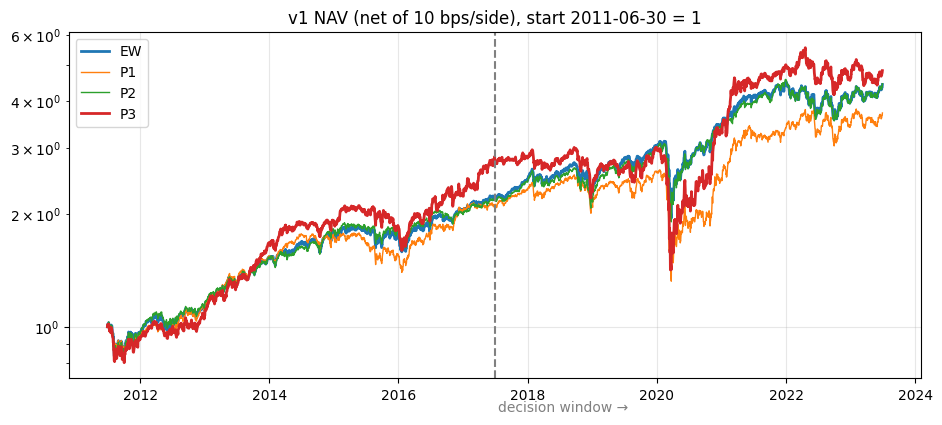

In [8]:
fig, ax = plt.subplots(figsize=(11, 4.5))
for k in PORTS:
    n = res[("main", k)]["nav"]; ax.plot(n.index, n / n.iloc[0], label=k, lw=2 if k in ("P3", "EW") else 1)
ax.axvline(pd.Timestamp("2017-06-30"), color="gray", ls="--"); ax.text(pd.Timestamp("2017-07-15"), ax.get_ylim()[0]*1.05 if ax.get_ylim()[0]>0 else 1, "decision window →", color="gray")
ax.set_yscale("log"); ax.set_title("v1 NAV (net of 10 bps/side), start 2011-06-30 = 1"); ax.legend(); ax.grid(alpha=.3); plt.show()

## 6) Sensitivity ครบ 12 variant (รายงานทุกตัว — ไม่ใช้ตัดสิน) — แต่ละตัวเทียบ EW ของ universe ภายใต้กฎเดียวกัน

In [9]:
rows = []
for v in VARS:
    for wname in WIN:
        t = table(v, wname)
        for k in ["P1", "P2", "P3"]:
            rows.append({"variant": v, "portfolio": k, "window": wname, "avg_n": t.loc[k, "avg_n"],
                         "Sharpe": t.loc[k, "Sharpe"], "Sharpe_EW": t.loc["EW", "Sharpe"],
                         "Sharpe>EW": t.loc[k, "Sharpe"] > t.loc["EW", "Sharpe"],
                         "CAGR": t.loc[k, "CAGR"], "CAGR_EW": t.loc["EW", "CAGR"],
                         "excess_ann": t.loc[k, "excess_vs_EW_ann"], "NW_t": t.loc[k, "NW_t"]})
sens = pd.DataFrame(rows)
print("12 variant = (main, S1, S2, S3) × (P1, P2, P3) — แสดงทั้ง 2 ช่วง")
display(sens[sens.window.str.startswith("2017")].reset_index(drop=True))
display(sens[sens.window.str.startswith("2011")].reset_index(drop=True))

12 variant = (main, S1, S2, S3) × (P1, P2, P3) — แสดงทั้ง 2 ช่วง


,variant,portfolio,window,avg_n,Sharpe,Sharpe_EW,Sharpe>EW,CAGR,CAGR_EW,excess_ann,NW_t
0,main,P1,2017-2022 (ตัดสิน),60.8333,0.4467,0.6298,False,0.0993,0.1231,-0.0080,-0.1652
1,main,P2,2017-2022 (ตัดสิน),105.0000,0.6342,0.6298,True,0.1267,0.1231,0.0043,0.3433
2,main,P3,2017-2022 (ตัดสิน),13.0000,0.4097,0.6298,False,0.0985,0.1231,0.0052,0.0773
3,S1,P1,2017-2022 (ตัดสิน),65.8333,0.4860,0.6397,False,0.1094,0.1252,-0.0012,-0.0252
4,S1,P2,2017-2022 (ตัดสิน),106.1667,0.6314,0.6397,False,0.1260,0.1252,0.0018,0.1526
5,S1,P3,2017-2022 (ตัดสิน),12.1667,0.4203,0.6397,False,0.1017,0.1252,0.0057,0.0816
6,S2,P1,2017-2022 (ตัดสิน),62.1667,0.4596,0.6398,False,0.1031,0.1253,-0.0060,-0.1234
7,S2,P2,2017-2022 (ตัดสิน),113.0000,0.6413,0.6398,True,0.1289,0.1253,0.0045,0.3398
8,S2,P3,2017-2022 (ตัดสิน),14.1667,0.4244,0.6398,False,0.1035,0.1253,0.0088,0.1324
9,S3,P1,2017-2022 (ตัดสิน),60.6667,0.4412,0.6286,False,0.0978,0.1228,-0.0091,-0.1862


,variant,portfolio,window,avg_n,Sharpe,Sharpe_EW,Sharpe>EW,CAGR,CAGR_EW,excess_ann,NW_t
0,main,P1,2011-2016 (ประกอบ),49.0000,1.0923,1.1843,False,0.1323,0.1412,-0.0075,-0.3164
1,main,P2,2011-2016 (ประกอบ),76.8333,1.1129,1.1843,False,0.1385,0.1412,-0.0017,-0.1538
2,main,P3,2011-2016 (ประกอบ),8.5000,1.1717,1.1843,False,0.1835,0.1412,0.0416,1.1597
3,S1,P1,2011-2016 (ประกอบ),56.3333,1.1284,1.1346,False,0.1363,0.1366,-0.0002,-0.0100
4,S1,P2,2011-2016 (ประกอบ),78.1667,1.1038,1.1346,False,0.1375,0.1366,0.0014,0.1256
5,S1,P3,2011-2016 (ประกอบ),8.3333,1.2156,1.1346,True,0.1855,0.1366,0.0465,1.3459
6,S2,P1,2011-2016 (ประกอบ),50.1667,1.0960,1.1748,False,0.1319,0.1406,-0.0075,-0.3216
7,S2,P2,2011-2016 (ประกอบ),86.0000,1.0821,1.1748,False,0.1357,0.1406,-0.0036,-0.3710
8,S2,P3,2011-2016 (ประกอบ),9.8333,1.1128,1.1748,False,0.1614,0.1406,0.0215,0.6556
9,S3,P1,2011-2016 (ประกอบ),49.0000,1.0923,1.1854,False,0.1323,0.1410,-0.0074,-0.3094


## 7) Benchmark ภายนอก (รายงานประกอบ — มี survivorship เอียงเข้าข้างพอร์ตเรา)
SPY/RSP = total return (Adj Close), ^DJI = price only (ไม่รวมปันผล), TDEX.BK = THB และแปลงเป็น USD ด้วย THB=X, THD = USD

In [10]:
allpx = prices.load_adj_close().loc[:END]; allcl = prices.load_close().loc[:END]
bser = {"SPY (USD, TR)": allpx["SPY"], "RSP (USD, TR)": allpx["RSP"], "^DJI (USD, price)": allcl["^DJI"],
        "TDEX.BK (THB)": allpx["TDEX.BK"], "TDEX.BK (USD)": allpx["TDEX.BK"] / allcl["THB=X"].reindex(allpx.index).ffill(),
        "THD (USD)": allpx["THD"]}
brow = []
for name, s in bser.items():
    s = s.dropna(); r = bt.monthly(s)
    for wname, (a, b) in WIN.items():
        m = bt.metrics(bt.window(r, a, b), rf, s[(s.index >= a) & (s.index <= b)])
        brow.append({"benchmark": name, "window": wname, "first_date": s.index.min().date(), **m})
for k in ["EW", "P3"]:
    for wname, (a, b) in WIN.items():
        n = res[("main", k)]["nav"]
        brow.append({"benchmark": f"{k} (ของเรา)", "window": wname, "first_date": n.index.min().date(),
                     **bt.metrics(bt.window(mret[("main", k)], a, b), rf, n[(n.index >= a) & (n.index <= b)])})
display(pd.DataFrame(brow).sort_values(["window", "benchmark"]).reset_index(drop=True))

,benchmark,window,first_date,months,CAGR,vol,Sharpe,maxDD
0,EW (ของเรา),2011-2016 (ประกอบ),2011-06-30,72,0.1412,0.1166,1.1843,-0.1993
1,P3 (ของเรา),2011-2016 (ประกอบ),2011-06-30,72,0.1835,0.1534,1.1717,-0.2412
2,"RSP (USD, TR)",2011-2016 (ประกอบ),2008-01-02,72,0.1229,0.1261,0.9751,-0.2288
3,"SPY (USD, TR)",2011-2016 (ประกอบ),2008-01-02,72,0.1292,0.1132,1.1230,-0.1837
4,TDEX.BK (THB),2011-2016 (ประกอบ),2008-01-02,72,0.0773,0.1506,0.5634,-0.2637
5,TDEX.BK (USD),2011-2016 (ประกอบ),2008-01-02,72,0.0592,0.1968,0.3855,-0.3953
6,THD (USD),2011-2016 (ประกอบ),2008-04-01,72,0.0623,0.2058,0.3922,-0.3799
7,"^DJI (USD, price)",2011-2016 (ประกอบ),2008-01-02,72,0.0946,0.1110,0.8602,-0.1626
8,EW (ของเรา),2017-2022 (ตัดสิน),2011-06-30,72,0.1231,0.1894,0.6298,-0.3770
9,P3 (ของเรา),2017-2022 (ตัดสิน),2011-06-30,72,0.0985,0.3034,0.4097,-0.5290


## 8) Rank IC และ quintile spread (ผลตอบแทน 12 เดือนถัดไป ภายใน universe main)

In [11]:
fwd = res[("main", "EW")]["fwd"]
s = scores[scores.elig_main].drop_duplicates(["R", "yahoo"]).merge(fwd, on=["R", "yahoo"])
ic_rows = []
for R, g in s.groupby("R"):
    pos = g[g.BM > 0].copy()
    pos["q"] = pd.qcut(pos.BM.rank(method="first"), 5, labels=False)
    g = g.sort_values(["F_main", "yahoo"]).copy(); g["qf"] = pd.qcut(g.F_main.rank(method="first"), 5, labels=False)
    ic_rows.append({"R": R.date(), "IC_BM": pos.BM.corr(pos.fwd, method="spearman"),
                    "IC_F": g.F_main.corr(g.fwd, method="spearman"),
                    "BM_Q5_minus_Q1": pos[pos.q == 4].fwd.mean() - pos[pos.q == 0].fwd.mean(),
                    "F_Q5_minus_Q1": g[g.qf == 4].fwd.mean() - g[g.qf == 0].fwd.mean(), "n": len(g)})
ic = pd.DataFrame(ic_rows); display(ic)
ic["window"] = np.where(pd.to_datetime(ic.R) >= pd.Timestamp("2017-01-01"), "2017-2022 (ตัดสิน)", "2011-2016 (ประกอบ)")
display(ic.groupby("window")[["IC_BM", "IC_F", "BM_Q5_minus_Q1", "F_Q5_minus_Q1"]].mean())

,R,IC_BM,IC_F,BM_Q5_minus_Q1,F_Q5_minus_Q1,n
0,2011-06-30,-0.0961,0.0067,-0.1186,-0.0002,169
1,2012-06-29,0.1117,-0.0281,0.1371,-0.0676,238
2,2013-06-28,0.1291,-0.0377,0.0656,-0.0688,259
3,2014-06-30,-0.2629,0.0765,-0.2518,0.0623,266
4,2015-06-30,-0.0162,0.0637,0.0183,0.0116,275
5,2016-06-30,-0.0315,0.0091,0.0506,-0.0560,290
6,2017-06-30,-0.1438,-0.0564,-0.0974,-0.0802,297
7,2018-06-29,-0.1539,-0.0336,-0.1483,-0.0385,306
8,2019-06-28,-0.4273,0.0273,-0.3505,0.0060,306
9,2020-06-30,0.2057,-0.0472,0.2924,-0.0446,319


,IC_BM,IC_F,BM_Q5_minus_Q1,F_Q5_minus_Q1
window,,,,
2011-2016 (ประกอบ),-0.0277,0.0151,-0.0165,-0.0198
2017-2022 (ตัดสิน),-0.0803,0.0066,-0.0433,-0.0300


## 9) แยกกลุ่มอุตสาหกรรม (SIC, ไม่ใช่ GICS) — ช่วงตัดสิน

In [12]:
sd = s[pd.to_datetime(s.R) >= "2017-01-01"].copy(); sd["group"] = sd.sic.map(audit.sic_group)
comp = {}
for k in PORTS:
    names = {(R, y) for R in Rs if R >= pd.Timestamp("2017-01-01") for y in hold["main"][R][k]}
    x = sd[[(r, y) in names for r, y in zip(sd.R, sd.yahoo)]]
    comp[f"{k}_share_%"] = x.group.value_counts(normalize=True) * 100
    comp[f"{k}_mean_fwd"] = x.groupby("group").fwd.mean()
display(pd.DataFrame(comp).sort_values("EW_share_%", ascending=False).round(3))

,EW_share_%,EW_mean_fwd,P1_share_%,P1_mean_fwd,P2_share_%,P2_mean_fwd,P3_share_%,P3_mean_fwd
group,,,,,,,,
Business services & software,11.0020,0.1450,3.0140,-0.0870,13.3330,0.2080,3.8460,-0.2020
Instruments & medical devices,10.2230,0.1380,2.1920,-0.0070,12.0630,0.1910,5.1280,0.0210
Retail,8.9780,0.1940,3.8360,0.2320,10.9520,0.2040,7.6920,-0.0540
Utilities,8.9260,0.0880,23.2880,0.0870,2.8570,0.0900,7.6920,0.0130
Other manufacturing,8.1470,0.0980,10.1370,0.2030,10.6350,0.0880,14.1030,0.0920
Machinery & computers,7.0580,0.1720,7.6710,0.0520,7.6190,0.2250,10.2560,0.1850
Chemicals & pharma,6.3310,0.1160,3.2880,0.0500,7.4600,0.0900,5.1280,-0.0250
Electronics & semis,6.2270,0.2060,3.0140,0.2290,6.8250,0.2230,5.1280,0.2890
Transportation,5.2930,0.0950,5.2050,0.2280,3.4920,0.1180,11.5380,0.1050


## 10) Lumpsum และ DCA (main)

In [13]:
lrows = []
for wname, (a, b) in WIN.items():
    for k in PORTS:
        lrows.append({"window": wname, "portfolio": k, **bt.dca(res[("main", k)]["nav"], a, b)})
    lrows.append({"window": wname, "portfolio": "SPY (ประกอบ)", **bt.dca(allpx["SPY"].dropna(), a, b)})
display(pd.DataFrame(lrows))

,window,portfolio,dca_final_over_invested,dca_IRR,lumpsum_multiple
0,2011-2016 (ประกอบ),EW,1.5491,0.1447,2.2086
1,2011-2016 (ประกอบ),P1,1.5118,0.1366,2.1079
2,2011-2016 (ประกอบ),P2,1.5195,0.1383,2.1775
3,2011-2016 (ประกอบ),P3,1.8741,0.2085,2.7477
4,2011-2016 (ประกอบ),SPY (ประกอบ),1.4940,0.1327,2.0734
5,2017-2022 (ตัดสิน),EW,1.4421,0.1210,2.0068
6,2017-2022 (ตัดสิน),P1,1.4445,0.1215,1.7651
7,2017-2022 (ตัดสิน),P2,1.4760,0.1287,2.0456
8,2017-2022 (ตัดสิน),P3,1.5284,0.1403,1.7567
9,2017-2022 (ตัดสิน),SPY (ประกอบ),1.4341,0.1192,2.0321


## 11) รายชื่อหุ้นใน P3 ต่อรอบ (ความโปร่งใส)

In [14]:
for R in Rs:
    print(R.date(), len(hold["main"][R]["P3"]), ", ".join(hold["main"][R]["P3"]))

2011-06-30 12 COP, CVS, DUK, DVN, GE, GLW, LOW, MSI, NOC, RSG, TMO, XRX
2012-06-29 8 ATI, BSX, COP, FIS, NUE, R, RSG, XRX
2013-06-28 5 CF, CVS, HP, VMC, XRX
2014-06-30 12 GE, GHC, GLW, KSS, OXY, RIG, RSG, SJM, T, VMC, VZ, WHR
2015-06-30 11 EIX, GLW, HPQ, LUMN, MLM, MU, NUE, PEG, PVH, RCL, WDC
2016-06-30 3 LUMN, PVH, WDC
2017-06-30 8 CCL, CHTR, DTE, EIX, GLW, GT, M, PWR
2018-06-29 7 CVS, CVX, DTE, NCLH, PRGO, PVH, RCL
2019-06-28 19 BWA, CCL, CVX, EMN, FCX, GAP, JCI, KMI, KSS, MU, NCLH, NEM, NUE, PSX, PVH, QRVO, WDC, XOM, XRX
2020-06-30 7 ALK, COP, DAL, JCI, MGM, TPR, UAL
2021-06-30 9 BIO, CTVA, CVS, DGX, FTV, MOS, PEG, SJM, UHS
2022-06-30 28 ADM, ALK, CAG, CTVA, CVS, DXC, FIS, GM, GPN, HPE, IP, IR, JCI, KMI, LUMN, MHK, MOS, MPC, MU, NUE, NWL, PVH, TAP, WAB, WDC, WHR, XRAY, ZBH


In [15]:
# เก็บผลไว้ใช้ใน v9 (ไม่รวม held-out)
out = {"t_dec": t_dec, "t_info": t_info, "sens": sens, "ic": ic, "counts": cnt}
for k_, v_ in out.items(): v_.to_csv(INTERIM / f"v1_{k_}.csv")
pd.concat({f"{v}|{k}": res[(v, k)]["nav"] for v in VARS for k in PORTS}, axis=1).to_parquet(INTERIM / "v1_nav.parquet")
print("saved")

saved


## 13) ส่วนเพิ่มหลังผู้ใช้ตรวจ v1 (ข้อมูลเดิม in-sample — ไม่ได้เปลี่ยนการตั้งค่าใด ๆ ของ v1)
**13.1 หุ้นใน P3 รอบ 2019 และ 2020 พร้อมผลตอบแทนรายตัวตลอดรอบ** (ราคา R → R ถัดไป, หุ้นที่ราคาหยุด = เงินสด 0% ตามกฎ)

In [16]:
fw = res[("main", "P3")]["fwd"]
info = scores[scores.elig_main].drop_duplicates(["R", "yahoo"])[["R", "yahoo", "ticker", "cik", "sic", "BM", "F_main"]]
sec_name = rss.sort_values("filed").groupby("cik").name.last()
ew_fwd = res[("main", "EW")]["fwd"].groupby("R").fwd.mean()
for R in [pd.Timestamp("2019-06-28"), pd.Timestamp("2020-06-30")]:
    x = fw[fw.R == R].merge(info, on=["R", "yahoo"], how="left")
    x["sic_group"] = x.sic.map(audit.sic_group)
    x["company_sec"] = x.cik.map(sec_name)
    x = x.sort_values("fwd")
    print(f"รอบ {R.date()}: {len(x)} ตัว | ผลตอบแทนเฉลี่ย (equal-weight, ก่อนต้นทุน) = {x.fwd.mean():.2%} | EW universe = {ew_fwd[R]:.2%}")
    display(x[["ticker", "yahoo", "company_sec", "sic_group", "BM", "F_main", "fwd"]].reset_index(drop=True))

รอบ 2019-06-28: 19 ตัว | ผลตอบแทนเฉลี่ย (equal-weight, ก่อนต้นทุน) = -16.97% | EW universe = -1.72%


,ticker,yahoo,company_sec,sic_group,BM,F_main,fwd
0,NCLH,NCLH,Norwegian Cruise Line Holdings Ltd.,Transportation,0.5107,7.8750,-0.6936
1,CCL,CCL,Carnival Corp Ltd.,Transportation,0.9969,8.0000,-0.6350
2,XRX,XRX,XEROX CORP,Machinery & computers,0.6153,7.8750,-0.5485
3,KSS,KSS,KOHLS Corp,Retail,0.7124,7.0000,-0.5347
4,PVH,PVH,PVH CORP. /DE/,Other manufacturing,0.8194,9.0000,-0.4912
5,XOM,XOM,EXXON MOBIL CORP,Petroleum refining,0.5910,9.0000,-0.3817
6,GPS,GAP,GAP INC,Retail,0.5222,7.0000,-0.2680
7,CVX,CVX,CHEVRON CORP,Petroleum refining,0.6537,8.0000,-0.2490
8,KMI,KMI,"KINDER MORGAN, INC.",Utilities,0.7125,8.0000,-0.2334
9,NUE,NUE,NUCOR CORP,Other manufacturing,0.5819,8.0000,-0.2201


รอบ 2020-06-30: 7 ตัว | ผลตอบแทนเฉลี่ย (equal-weight, ก่อนต้นทุน) = 101.28% | EW universe = 49.99%


,ticker,yahoo,company_sec,sic_group,BM,F_main,fwd
0,COP,COP,CONOCOPHILLIPS,Petroleum refining,0.7700,7.0000,0.5073
1,UAL,UAL,"United Airlines Holdings, Inc.",Transportation,1.3437,7.8750,0.5108
2,DAL,DAL,"DELTA AIR LINES, INC.",Transportation,0.8554,7.8750,0.5422
3,ALK,ALK,"ALASKA AIR GROUP, INC.",Transportation,0.9718,9.0000,0.6633
4,JCI,JCI,Johnson Controls International plc,Machinery & computers,0.7505,7.0000,1.0519
5,MGM,MGM,MGM Resorts International,Services (hotels/personal),0.9340,7.8750,1.5396
6,TPR,TPR,"TAPESTRY, INC.",Other manufacturing,0.9223,8.0000,2.2741


**13.2 rank IC รายปีของ BM และ F-score** — ดูว่าค่าเฉลี่ยติดลบกระจุกที่ปีใด (ตารางหัวข้อ 8 แยกรายรอบ; ที่นี่สรุปความกระจุก)

In [17]:
y = ic[["R", "window", "IC_BM", "IC_F"]].copy(); display(y)
for w_, g in y.groupby("window"):
    for col in ["IC_BM", "IC_F"]:
        worst = g.loc[g[col].idxmin()]
        print(f"{w_} {col}: เฉลี่ย {g[col].mean():+.4f} | ติดลบ {int((g[col] < 0).sum())}/{len(g)} ปี | "
              f"ปีที่แย่สุด {worst.R} ({worst[col]:+.4f}) | เฉลี่ยถ้าตัดปีที่แย่สุด {g.drop(worst.name)[col].mean():+.4f} | "
              f"median {g[col].median():+.4f}")

,R,window,IC_BM,IC_F
0,2011-06-30,2011-2016 (ประกอบ),-0.0961,0.0067
1,2012-06-29,2011-2016 (ประกอบ),0.1117,-0.0281
2,2013-06-28,2011-2016 (ประกอบ),0.1291,-0.0377
3,2014-06-30,2011-2016 (ประกอบ),-0.2629,0.0765
4,2015-06-30,2011-2016 (ประกอบ),-0.0162,0.0637
5,2016-06-30,2011-2016 (ประกอบ),-0.0315,0.0091
6,2017-06-30,2017-2022 (ตัดสิน),-0.1438,-0.0564
7,2018-06-29,2017-2022 (ตัดสิน),-0.1539,-0.0336
8,2019-06-28,2017-2022 (ตัดสิน),-0.4273,0.0273
9,2020-06-30,2017-2022 (ตัดสิน),0.2057,-0.0472


2011-2016 (ประกอบ) IC_BM: เฉลี่ย -0.0277 | ติดลบ 4/6 ปี | ปีที่แย่สุด 2014-06-30 (-0.2629) | เฉลี่ยถ้าตัดปีที่แย่สุด +0.0194 | median -0.0238
2011-2016 (ประกอบ) IC_F: เฉลี่ย +0.0151 | ติดลบ 2/6 ปี | ปีที่แย่สุด 2013-06-28 (-0.0377) | เฉลี่ยถ้าตัดปีที่แย่สุด +0.0256 | median +0.0079
2017-2022 (ตัดสิน) IC_BM: เฉลี่ย -0.0803 | ติดลบ 4/6 ปี | ปีที่แย่สุด 2019-06-28 (-0.4273) | เฉลี่ยถ้าตัดปีที่แย่สุด -0.0109 | median -0.1489
2017-2022 (ตัดสิน) IC_F: เฉลี่ย +0.0066 | ติดลบ 3/6 ปี | ปีที่แย่สุด 2017-06-30 (-0.0564) | เฉลี่ยถ้าตัดปีที่แย่สุด +0.0192 | median -0.0032


## 12) สรุป (ตาราง/ผลตัดสินสร้างจากผลที่คำนวณในรอบนี้โดยอัตโนมัติ)

In [18]:
from IPython.display import Markdown
spy_dec = [x for x in brow if x["benchmark"].startswith("SPY") and x["window"].startswith("2017")][0]
def fmt_row(name, win, m, ex=None):
    exs = "—" if ex is None else f"{m['excess_vs_EW_ann']*100:+.1f}% ({m['NW_t']:.2f})"
    return f"| {name} | {win} | {m['CAGR']*100:.1f}% | {m['vol']*100:.1f}% | {m['Sharpe']:.3f} | {m['maxDD']*100:.1f}% | {m.get('avg_n', float('nan')):.0f} | {exs} |"
lines = ["| พอร์ต | ช่วง | CAGR | Vol | Sharpe | Max DD | หุ้นเฉลี่ย | ส่วนเกิน vs EW/ปี (NW t) |", "|---|---|---|---|---|---|---|---|"]
for tbl, win in [(t_dec, "2017–2022 (ตัดสิน)"), (t_info, "2011–2016 (ประกอบ)")]:
    for k, name in [("EW", "EW universe"), ("P1", "P1 High BM"), ("P2", "P2 High F"), ("P3", "**P3 BM+F**")]:
        lines.append(fmt_row(name, win, tbl.loc[k], None if k == "EW" else True))
    if win.startswith("2017"):
        lines.append(f"| SPY (ประกอบ ⚠️) | {win} | {spy_dec['CAGR']*100:.1f}% | {spy_dec['vol']*100:.1f}% | {spy_dec['Sharpe']:.3f} | {spy_dec['maxDD']*100:.1f}% | — | — |")
verdict = "ผ่าน" if C1 else "ไม่ผ่าน"
display(Markdown(f"### ผลตัดสิน: **C1 {verdict}** (ชั่วคราว — C2 ของ held-out ประเมินครั้งเดียวในขั้น Final)\n"
                 f"ช่วงตัดสิน: Sharpe P3 = **{sh_p3:.3f}** เทียบ EW = **{sh_ew:.3f}**\n\n" + "\n".join(lines)))
d = sens[sens.window.str.startswith("2017")]
p3 = d[d.portfolio == "P3"]; p2 = d[d.portfolio == "P2"]
print(f"sensitivity ช่วงตัดสิน: P3 Sharpe {p3.Sharpe.min():.3f}–{p3.Sharpe.max():.3f} vs EW {p3.Sharpe_EW.min():.3f}–{p3.Sharpe_EW.max():.3f}; "
      f"P2 > EW {int(p2['Sharpe>EW'].sum())}/4 (ส่วนต่างสูงสุด {(p2.Sharpe - p2.Sharpe_EW).max():.4f}); P1 > EW {int(d[d.portfolio=='P1']['Sharpe>EW'].sum())}/4")

### ผลตัดสิน: **C1 ไม่ผ่าน** (ชั่วคราว — C2 ของ held-out ประเมินครั้งเดียวในขั้น Final)
ช่วงตัดสิน: Sharpe P3 = **0.410** เทียบ EW = **0.630**

| พอร์ต | ช่วง | CAGR | Vol | Sharpe | Max DD | หุ้นเฉลี่ย | ส่วนเกิน vs EW/ปี (NW t) |
|---|---|---|---|---|---|---|---|
| EW universe | 2017–2022 (ตัดสิน) | 12.3% | 18.9% | 0.630 | -37.7% | 321 | — |
| P1 High BM | 2017–2022 (ตัดสิน) | 9.9% | 24.9% | 0.447 | -49.5% | 61 | -0.8% (-0.17) |
| P2 High F | 2017–2022 (ตัดสิน) | 12.7% | 19.5% | 0.634 | -38.3% | 105 | +0.4% (0.34) |
| **P3 BM+F** | 2017–2022 (ตัดสิน) | 9.8% | 30.3% | 0.410 | -52.9% | 13 | +0.5% (0.08) |
| SPY (ประกอบ ⚠️) | 2017–2022 (ตัดสิน) | 12.5% | 17.4% | 0.681 | -33.7% | — | — |
| EW universe | 2011–2016 (ประกอบ) | 14.1% | 11.7% | 1.184 | -19.9% | 250 | — |
| P1 High BM | 2011–2016 (ประกอบ) | 13.2% | 12.0% | 1.092 | -21.5% | 49 | -0.8% (-0.32) |
| P2 High F | 2011–2016 (ประกอบ) | 13.8% | 12.3% | 1.113 | -21.0% | 77 | -0.2% (-0.15) |
| **P3 BM+F** | 2011–2016 (ประกอบ) | 18.3% | 15.3% | 1.172 | -24.1% | 8 | +4.2% (1.16) |

sensitivity ช่วงตัดสิน: P3 Sharpe 0.400–0.424 vs EW 0.629–0.640; P2 > EW 3/4 (ส่วนต่างสูงสุด 0.0052); P1 > EW 0/4


### อ่านผลแบบง่าย (ดูตัวเลขจากตารางด้านบน)
- **ช่วงตัดสิน 2017–2022:** "หุ้นถูก" (P1) แพ้การซื้อทุกตัว (EW) และ rank IC ของ BM ติดลบเกือบทุกปี (หัวข้อ 8 และ 13.2) — ความถูกไม่ได้ช่วย
  "หุ้นงบแข็งแรง" (P2) ใกล้เคียง EW มาก — คุณภาพไม่ได้ทำร้าย แต่ก็แทบไม่ได้ช่วย
  P3 เหลือหุ้นแค่ ~13 ตัว เป็นหุ้นวัฏจักรที่แกว่งแรงทั้งสองทาง (หัวข้อ 13.1: รอบ 2019 เรือสำราญขาดทุนหนักช่วงโควิด;
  รอบ 2020 สายการบิน/คาสิโนฟื้นแรง) → Sharpe ต่ำสุดในสามพอร์ต
  *แก้ถ้อยคำหลังผู้ใช้ขอตรวจ: ร่างแรกเขียนว่า "โดนหนักช่วงโควิด (รอบ 2019–2020 มีเรือสำราญ/สายการบิน)" ซึ่งถูกแค่ครึ่งเดียว*
- **ช่วงประกอบ 2011–2016:** P3 ได้ CAGR สูงกว่า EW แต่ Sharpe ยังต่ำกว่าเล็กน้อย และถือแค่ 3–12 ตัว; survivorship สูงสุด → เชื่อถือได้น้อย
- **ablation:** ใน S&P 500 ช่วงนี้ ทั้งความถูกและคุณภาพไม่ได้ชนะ EW อย่างมีนัย — ถ้าต้องเลือกอันที่ "ไม่แย่" คือคุณภาพ (P2)
- **Sensitivity 12 variant** (หัวข้อ 6 และบรรทัดสรุปด้านบน): การจัดการข้อมูลขาดและการตัด IR/JEF ไม่เปลี่ยนข้อสรุป
- **DCA** (หัวข้อ 10): ผลขึ้นกับจังหวะวิกฤต (ได้ซื้อ P3 ตอนตกหนักปี 2020) ไม่ใช่ความสามารถของสัญญาณ

### บั๊กที่พบและแก้ (ประวัติการรันตามจริง — C1 ไม่ผ่านทุกรอบ)
| รอบ | บั๊กที่ยังอยู่ในรอบนั้น | Sharpe P3 / EW |
|---|---|---|
| 1 | ตัดประวัติ split ที่ END → market cap หุ้นที่ split หลัง 2023 เล็กไป (NVDA 2017 เล็กไป 10 เท่า) | 0.6125 / 0.6294 |
| 2 | ไม่ปรับจำนวนหุ้นด้วย split ระหว่างวันนับหุ้นกับ R (AMZN 2022 เล็กไป 20 เท่า) | 0.4614 / 0.6301 |
| 3 | ticker reuse ที่ market cap > $1B (IR 2017–2019 ใช้ราคาของ Gardner Denver) | 0.4493 / 0.6305 |
| 4 | งบปีก่อน (t−1) หยิบแถวว่าง ณ วันเริ่มใช้มาตรฐานบัญชี (เช่น 2018-01-01) → F-score หายบางส่วนในรอบ 2019–2020 (พบใน AUTORUN round 001) | 0.4115 / 0.6308 |
| ล่าสุด | — (ตรวจ market cap กับ public float ในหัวข้อ 1.1) | ดูผลตัดสินด้านบน |

### ข้อจำกัด
- survivorship: universe ไม่มีหุ้นที่หาราคาไม่ได้ → ผลของทุกพอร์ต (รวม EW) น่าจะสูงเกินจริง และการเทียบกับ SPY/RSP เอียงเข้าข้างเรา
- P3 มีหุ้น < 20 ตัวเกือบทุกรอบ (ตารางหัวข้อ 2) → ผลขึ้นกับหุ้นไม่กี่ตัวมาก
- market cap อาจคลาดเคลื่อนสำหรับบริษัทที่ออกหุ้นควบรวมหลังวันนับหุ้นบนหน้าปก และ DD 2012–2013
- กลุ่มอุตสาหกรรมใช้ SIC ไม่ใช่ GICS; ตัดกลุ่มการเงินออกทั้งหมด
- 12 variant (ต่อมาเป็นจุดเริ่มของ `trials.csv` ในโหมด AUTORUN) → ความเสี่ยง multiple testing; held-out ยังไม่ถูกแตะ

**ทดสอบแล้ว:** P1/P2/P3 + EW ทั้ง 2 ช่วง, sensitivity 12 variant, rank IC/quintile spread, แยก SIC, lumpsum/DCA, benchmark ภายนอก
**ยังเป็นแค่ไอเดีย:** ต่อยอดในโหมด AUTORUN (`model_A/AUTORUN.md`, `PREREG_AUTORUN.md`)